# Debugging chromatin deconvolution run time
December 2, 2024

The runtime with the padding increased from 2 hours to 8 hours. This is because the padding doubles the size of the f values to deconvolve. (Padding to the next power of 2 up for the wavelet to function properly). 

Thus, the current remedy is to reduce the number of intermediate indices to 64 per branch (as opposed to 128). This allows for each index to be approximately 1 minute in the final deconvolved f. And the runtime should be back to around 2 hours with the appropriate padding. What is lost is some temporal resolution in the deconvolution, but this may be okay given the amount of smooething we have chosen for the deconvolution.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [78]:
from src.GenomeDeconvolution import GenomeDeconvolution

outdir = "output/test"
genome_deconvolution = GenomeDeconvolution(save_dir=outdir)

In [115]:
genome_deconvolution.load_chrom_span(1, (10000, 11000))

Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution
Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution


In [116]:
genome_deconvolution.combined_model.deconvolve()

Deconvolving combined model with gamma=0.1
Deconvolving bin size: 10x10
of G shape: (31, 2600)
Padding type: both
Deconvolving with gamma=0.1
0/2600 - 00:00:00.116
500/2600 - 00:00:56.850
1000/2600 - 00:01:50.657
1500/2600 - 00:02:46.320
2000/2600 - 00:03:42.493
2500/2600 - 00:04:36.349
Deconvolved in : 00:04:48.001
The fitting norm is 1.45, the smoothing norm is: 2.20


In [117]:
from src.config import load_configs_by_config_type
config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')
i_indices = config.get_Hpositions_for_branch('i')

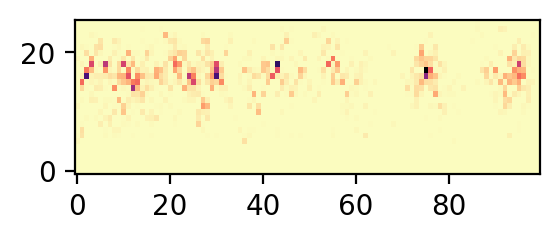

In [130]:
f = genome_deconvolution.combined_model.deconvolved_f_value
f_imgs = f.reshape((f.shape[0], 26, -1))
plt.figure(figsize=(3, 1))
plt.imshow(f_imgs[0], cmap='magma_r', vmin=0.9, origin='lower', aspect='auto')


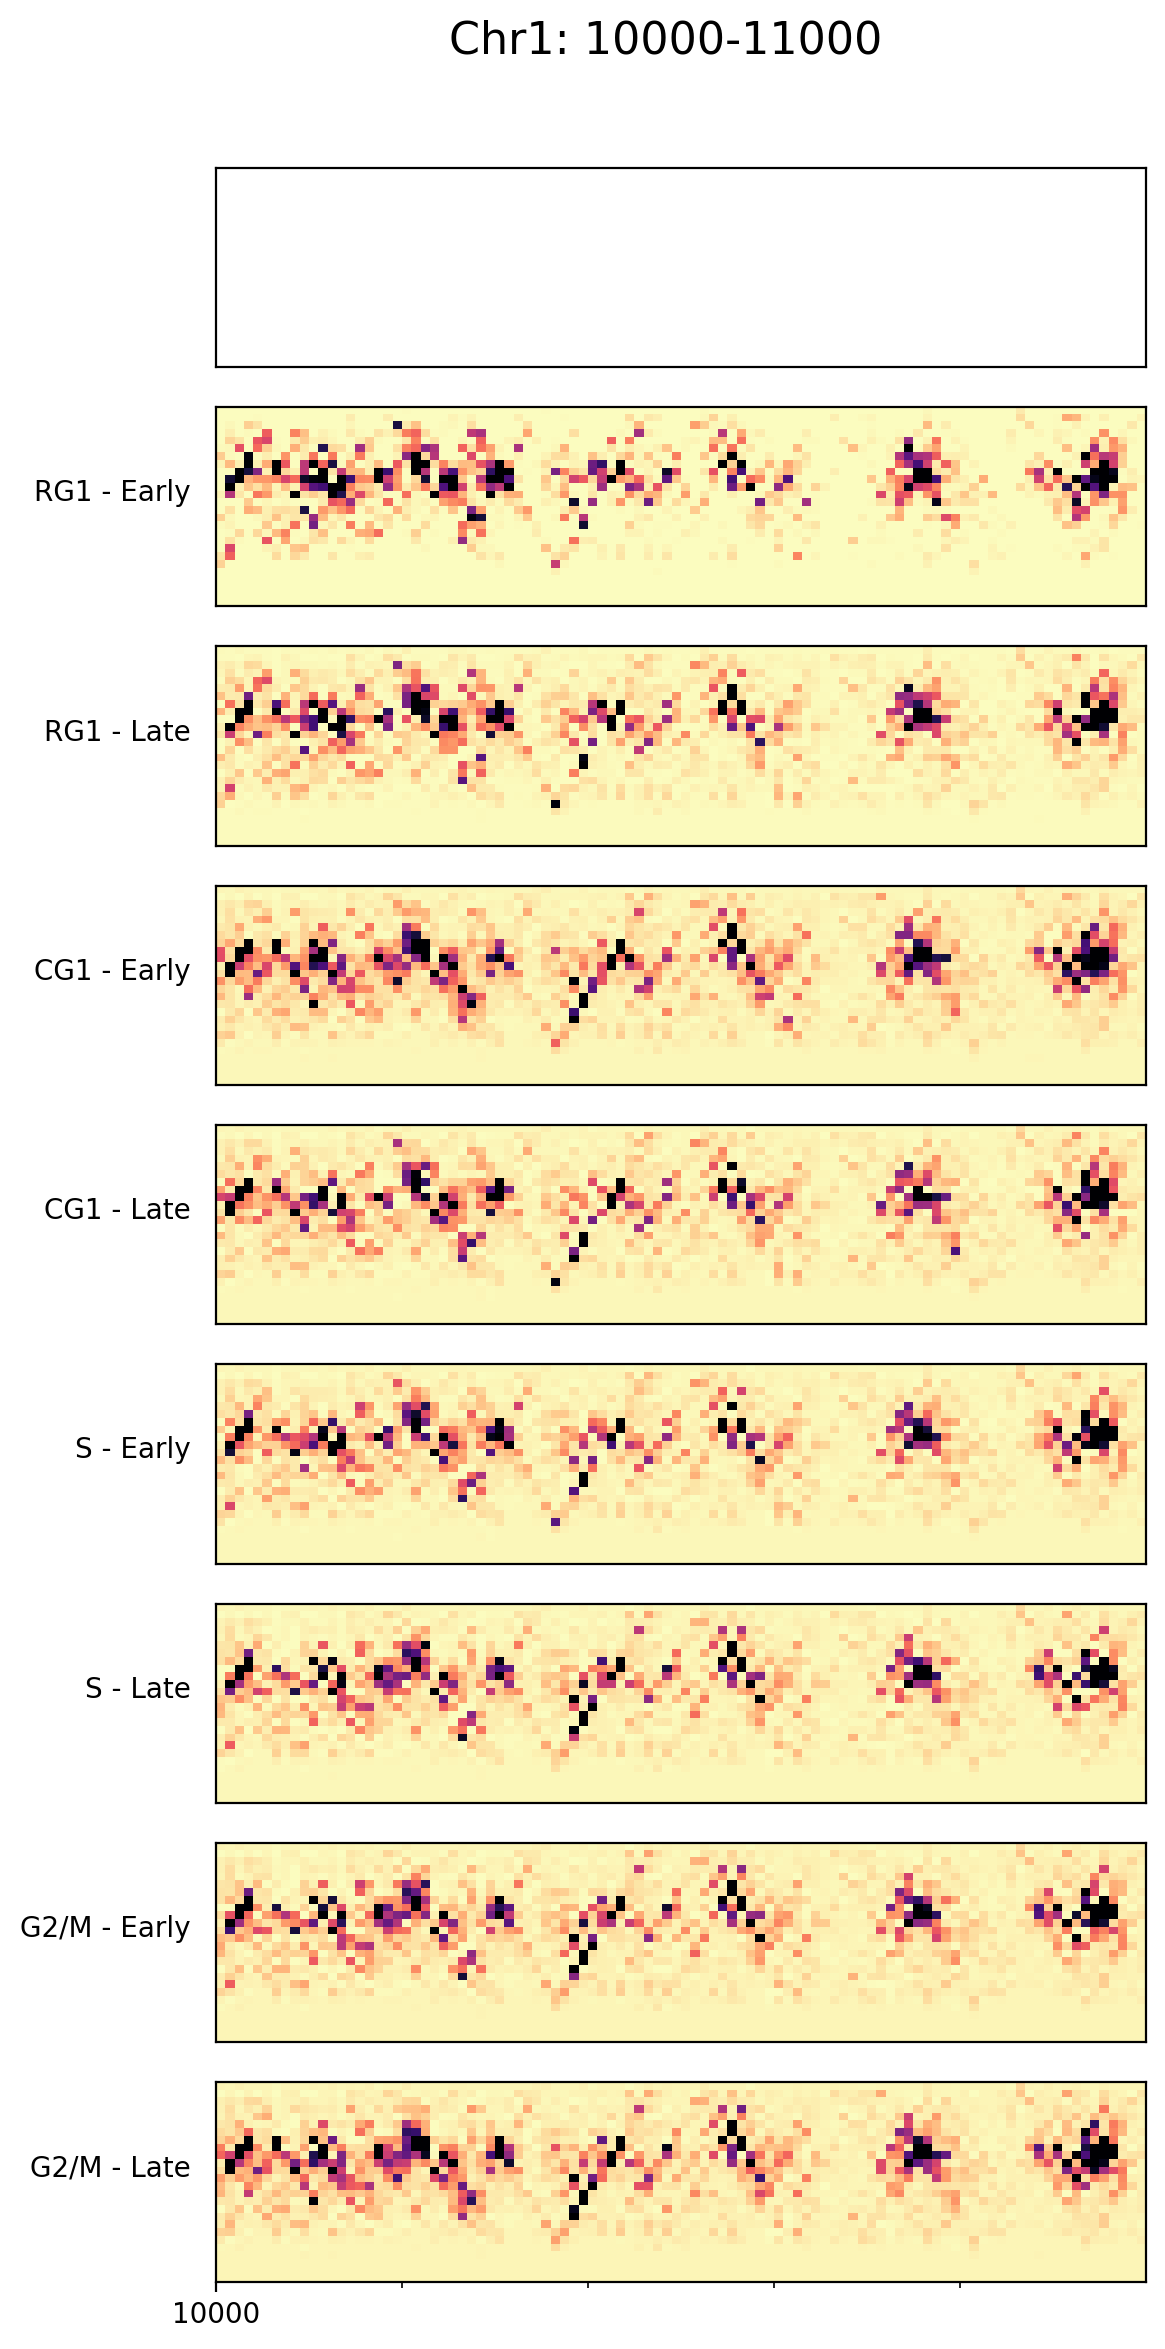

In [129]:
fig = genome_deconvolution.plot_deconvolved_result(figwidth=6)

In [120]:
plt.plot(genome_deconvolution.combined_model.deconvolved_f_value.mean(axis=1)[t_indices])
plt.plot(genome_deconvolution.combined_model.deconvolved_f_value.mean(axis=1)[i_indices])
plt.ylim(0, 2)

IndexError: index 84 is out of bounds for axis 0 with size 84

In [104]:
from src.create_models import create_wt1_model, create_wt2_model, SHORTENED_G1_LENGTH, SHORTENED_POSTG1_LENGTH

create_wt1_model('models/yl_cell_cycle/wt1_rg1_shortened.22.label', g1_length=SHORTENED_G1_LENGTH,
                postg1_length=SHORTENED_POSTG1_LENGTH)
create_wt2_model('models/yl_cell_cycle/wt2_rg1_shortened.20.label', g1_length=SHORTENED_G1_LENGTH,
                postg1_length=SHORTENED_POSTG1_LENGTH)


Created model and saved to file: models/yl_cell_cycle/wt1_rg1_shortened.22.label
Created model and saved to file: models/yl_cell_cycle/wt2_rg1_shortened.20.label


'models/yl_cell_cycle/wt2_rg1_shortened.20.label'

In [105]:
from src.model import Model
from src.config import load_combined_gene_expression_by_config_type

combined_model = load_combined_gene_expression_by_config_type('shared')
model = Model(combined_model, 'CLB2')


In [106]:
model.deconvolve_find_optimal_gamma()

In [111]:
model.gamma = 0.02
model.deconvolve()

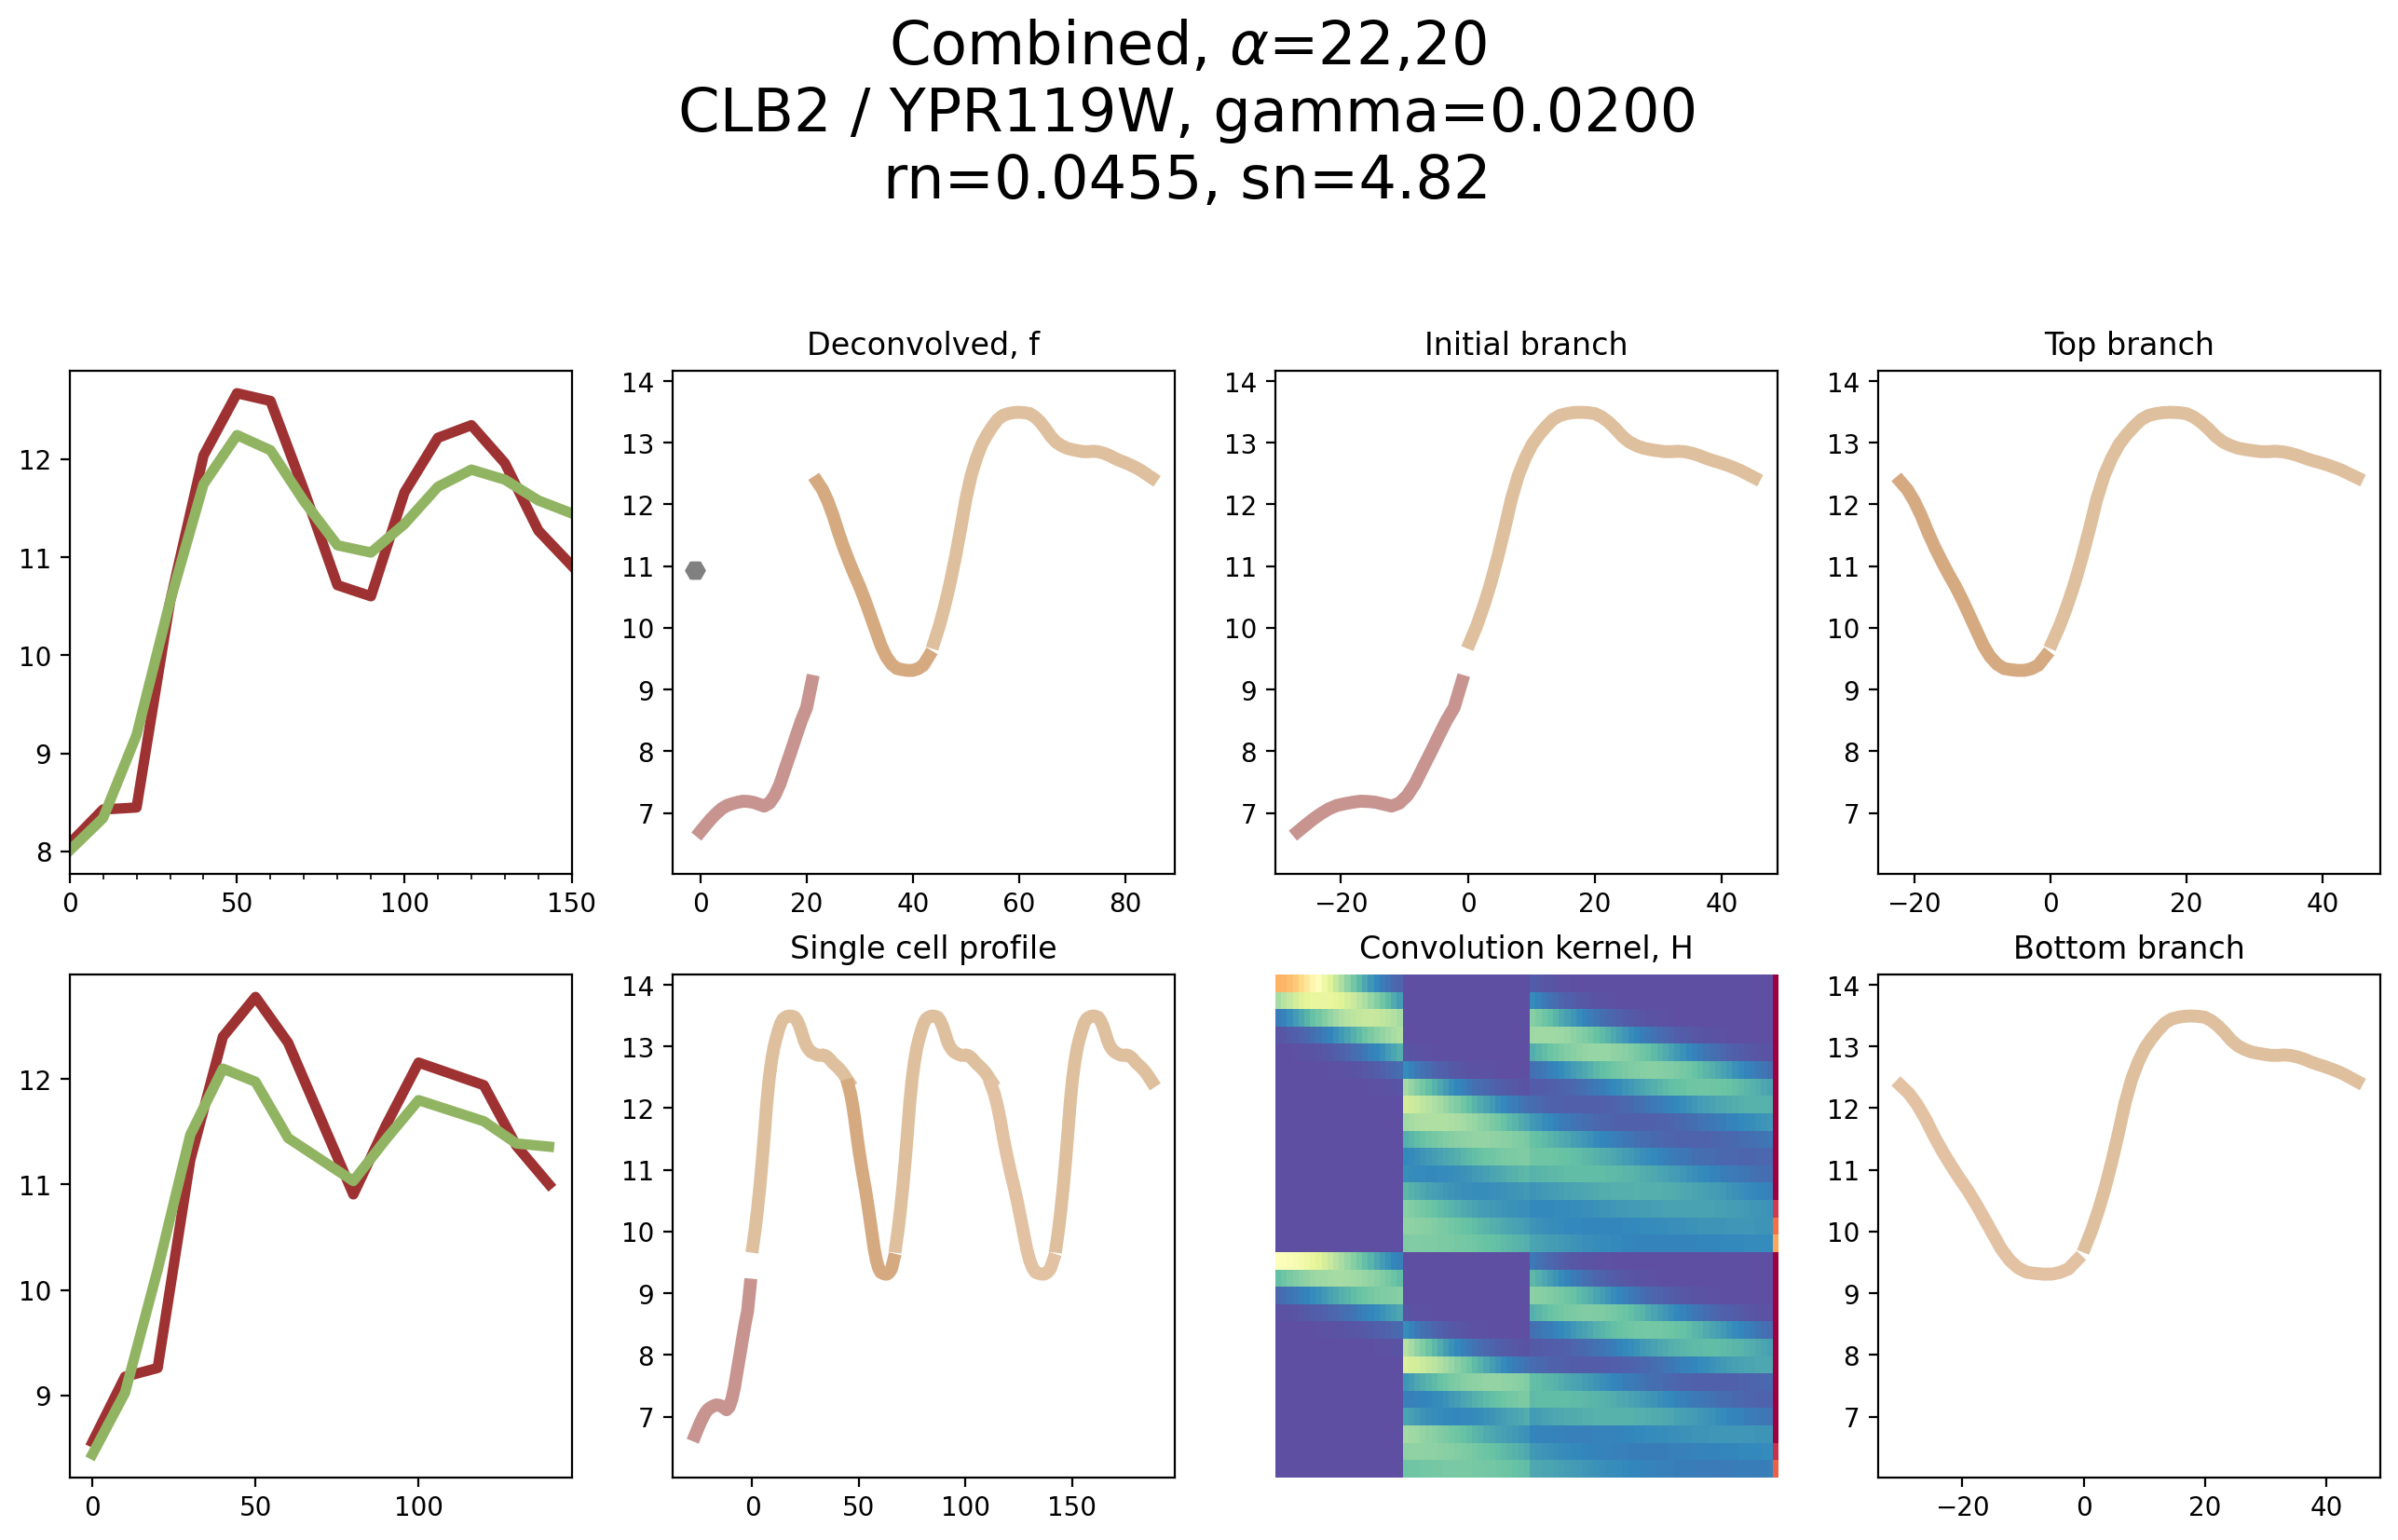

In [112]:
fig = model.plot_deconvolved_gene()

In [113]:
model.config.get_phase_timepoints_for_phase('CG1')

array([-22.    , -20.9873, -19.9746, -18.9619, -17.9492, -16.9365,
       -15.9237, -14.911 , -13.8983, -12.8856, -11.8729, -10.8602,
        -9.8475,  -8.8348,  -7.8221,  -6.8094,  -5.7967,  -4.784 ,
        -3.7712,  -2.7585,  -1.7458,  -0.7331])

In [114]:
model.config.get_phase_timepoints_for_phase('postG1')

array([ 0.2796,  1.3727,  2.4659,  3.559 ,  4.6521,  5.7453,  6.8384,
        7.9316,  9.0247, 10.1178, 11.211 , 12.3041, 13.3972, 14.4904,
       15.5835, 16.6767, 17.7698, 18.8629, 19.9561, 21.0492, 22.1424,
       23.2355, 24.3286, 25.4218, 26.5149, 27.608 , 28.7012, 29.7943,
       30.8875, 31.9806, 33.0737, 34.1669, 35.26  , 36.3532, 37.4463,
       38.5394, 39.6326, 40.7257, 41.8188, 42.912 , 44.0051, 45.0983])